In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch 
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torch.nn as nn

from sklearn.model_selection import train_test_split

In [30]:
device=torch.device(
"cuda" if torch.cuda.is_available else "cpu"
)
print("devices:",device)
if torch.cuda.is_available():
    print("gpu:",torch.cuda.get_device_name(0))

devices: cuda
gpu: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [31]:
data_dir = "garbage_classification"

print(os.listdir(data_dir))

['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [32]:
classes = sorted([
    folder
    for folder in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir,folder))
])
print("no. of classes:",len(classes))
print("classes:",classes)

no. of classes: 12
classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [33]:
#create our csv
records = []
for labels in classes:
    class_dir = os.path.join(data_dir,labels)
    for filename in os.listdir(class_dir):
        file_path = os.path.join(class_dir,filename)
        if filename.lower().endswith(
            (".jpg",".jpeg",".png")
        ):
            records.append({
                "image_path":file_path,
                "labels":labels
            })
       

In [34]:
df = pd.DataFrame(records)
print(df.tail(5))

df.to_csv("labels.csv",index=False)

                                              image_path       labels
15510  garbage_classification\white-glass\white-glass...  white-glass
15511  garbage_classification\white-glass\white-glass...  white-glass
15512  garbage_classification\white-glass\white-glass...  white-glass
15513  garbage_classification\white-glass\white-glass...  white-glass
15514  garbage_classification\white-glass\white-glass...  white-glass


Train / Validation / Test Split

In [35]:
df.shape
df["labels"].value_counts()


labels
clothes        5325
shoes          1977
paper          1050
biological      985
battery         945
cardboard       891
plastic         865
white-glass     775
metal           769
trash           697
green-glass     629
brown-glass     607
Name: count, dtype: int64

In [36]:
train_df,temp_df = train_test_split(
    df, test_size=0.2,random_state=42, stratify=df["labels"]
)
val_df,test_df = train_test_split(
    temp_df,test_size=0.5,random_state=42,stratify=temp_df["labels"]
)

In [37]:
print("total:",len(df)) 
print("train:",len(train_df))
print("validation:",len(val_df))
print("test:",len(test_df))
print(
    len(train_df)
    +len(val_df)
    +len(test_df)
)


total: 15515
train: 12412
validation: 1551
test: 1552
15515


In [38]:
train_df = train_df.reset_index(drop=True)
val_df= val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


In [39]:
import os
os.makedirs("data", exist_ok=True)

In [40]:
train_df.to_csv("data/train.csv",index=False)
val_df.to_csv("data/val.csv",index=False)
test_df.to_csv("data/test.csv",index=False)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 12412
Validation: 1551
Test: 1552


In [41]:
print(os.getcwd())
os.makedirs("data",exist_ok=True)
print(os.listdir("data"))

c:\ML PROJECTS\P4-DEEP LEARNING\CNN Image Classification
['test.csv', 'train.csv', 'val.csv']


Custom dataset

In [42]:
from torch.utils.data import Dataset
from PIL import Image


class WasteDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.classes = sorted(
            self.dataframe["labels"].unique()
        )

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(self.classes)
        }

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        label_name = row["labels"]

        image = Image.open(
            image_path
        ).convert("RGB")

        labels = self.class_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, labels
train_df.columns

Index(['image_path', 'labels'], dtype='str')

temporary dataset

In [43]:
train_dataset = WasteDataset(train_df)
print("Number of images:", len(train_dataset))
print("Classes:", train_dataset.classes)
print("Mapping:", train_dataset.class_to_idx)

Number of images: 12412
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Mapping: {'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}


Transform

In [44]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5],
                         std=[0.5,0.5,0.5])
])
val_test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean= [0.5,0.5,0.5],
        std = [0.5,0.5,0.5]
    )
])

Train: 12412
Validation: 1551
Test: 1552
Single image shape: torch.Size([3, 128, 128])
Single image label: 2
Images shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64
Minimum: -1.0
Maximum: 1.0


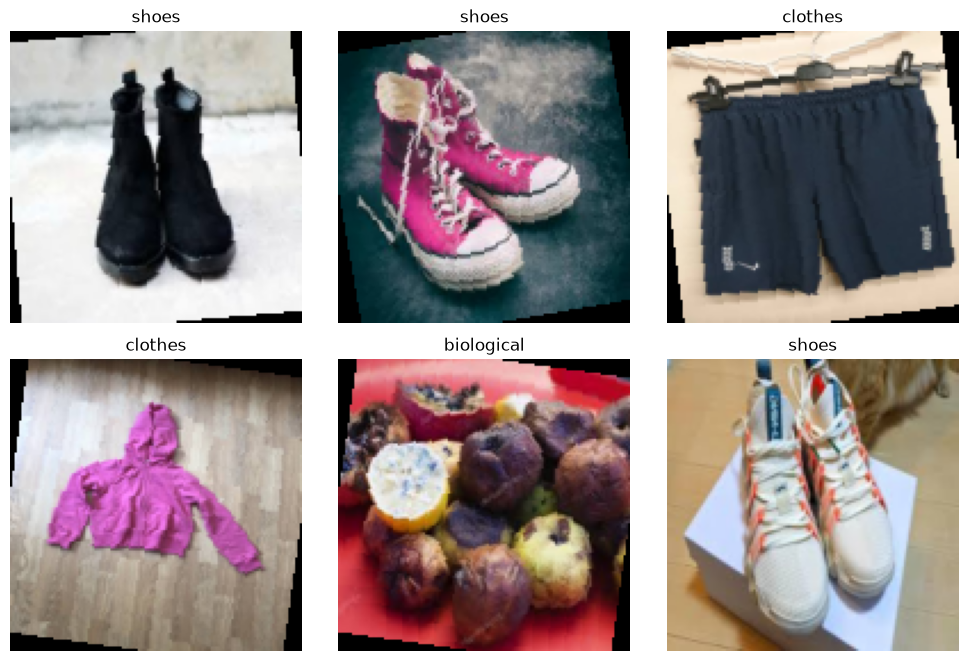

In [45]:
# ==========================================
# 1. CREATE DATASETS
# ==========================================

from torch.utils.data import DataLoader

train_dataset = WasteDataset(
    train_df,
    transform=train_transform
)

val_dataset = WasteDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = WasteDataset(
    test_df,
    transform=val_test_transform
)


# ==========================================
# 2. CHECK DATASET
# ==========================================

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

image, label = train_dataset[0]

print("Single image shape:", image.shape)
print("Single image label:", label)


# ==========================================
# 3. CREATE DATALOADERS
# ==========================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


# ==========================================
# 4. GET ONE BATCH
# ==========================================

images, labels = next(iter(train_loader))


# ==========================================
# 5. CHECK BATCH
# ==========================================

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("Minimum:", images.min().item())
print("Maximum:", images.max().item())


# ==========================================
# 6. VISUALIZE
# ==========================================

plt.figure(figsize=(10, 10))

for i in range(6):

    image = images[i]

    # CHW → HWC
    image = image.permute(1, 2, 0)

    # Reverse normalization for display
    image = image * 0.5 + 0.5

    plt.subplot(3, 3, i + 1)

    plt.imshow(image)

    plt.title(
        train_dataset.classes[
            labels[i].item()
        ]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
class WasteCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # Convolution Block 1
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Convolution Block 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Fully Connected Layers
        self.fc1 = nn.Linear(
            64 * 32 * 32,
            128
        )

        self.fc2 = nn.Linear(
            128,
            num_classes
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)

        return x

In [47]:
num_classes = len(train_dataset.classes)

model = WasteCNN(
    num_classes=num_classes
)
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

In [48]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 12])


In [49]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 12])


In [53]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 10

best_val_accuracy = 0.0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


for epoch in range(num_epochs):

    # =========================================
    # TRAINING
    # =========================================

    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_accuracy = (
        100 * train_correct /
        train_total
    )


    # =========================================
    # VALIDATION
    # =========================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    val_loss = (
        val_running_loss /
        len(val_loader)
    )

    val_accuracy = (
        100 * val_correct /
        val_total
    )


    # =========================================
    # SAVE HISTORY
    # =========================================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================================
    # SAVE BEST MODEL
    # =========================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_waste_cnn.pth"
        )


    # =========================================
    # PRINT
    # =========================================

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/10] Train Loss: 0.3257 Train Acc: 88.99% Val Loss: 0.9519 Val Acc: 75.05%
Epoch [2/10] Train Loss: 0.3032 Train Acc: 89.74% Val Loss: 0.9398 Val Acc: 75.82%
Epoch [3/10] Train Loss: 0.2565 Train Acc: 91.75% Val Loss: 1.0619 Val Acc: 77.56%
Epoch [4/10] Train Loss: 0.2449 Train Acc: 92.06% Val Loss: 0.9840 Val Acc: 75.56%
Epoch [5/10] Train Loss: 0.2184 Train Acc: 92.68% Val Loss: 0.9963 Val Acc: 76.60%
Epoch [6/10] Train Loss: 0.2148 Train Acc: 92.89% Val Loss: 1.0829 Val Acc: 77.50%
Epoch [7/10] Train Loss: 0.1840 Train Acc: 94.11% Val Loss: 1.1051 Val Acc: 76.79%
Epoch [8/10] Train Loss: 0.1754 Train Acc: 94.14% Val Loss: 1.1978 Val Acc: 75.95%
Epoch [9/10] Train Loss: 0.1539 Train Acc: 94.82% Val Loss: 1.3813 Val Acc: 75.50%
Epoch [10/10] Train Loss: 0.1561 Train Acc: 94.97% Val Loss: 1.1902 Val Acc: 77.24%


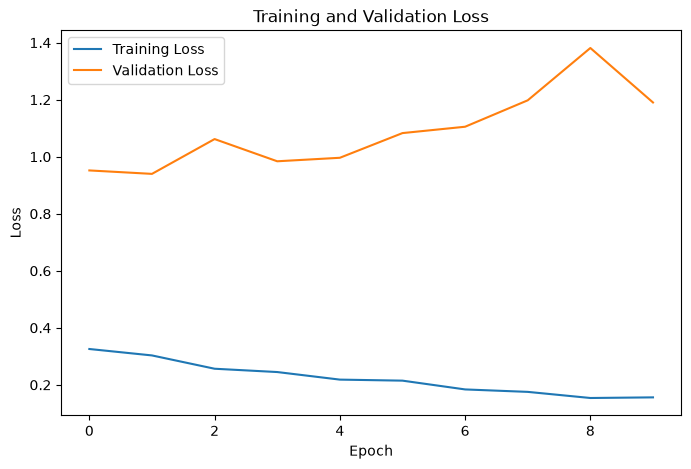

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")

plt.legend()

plt.show()

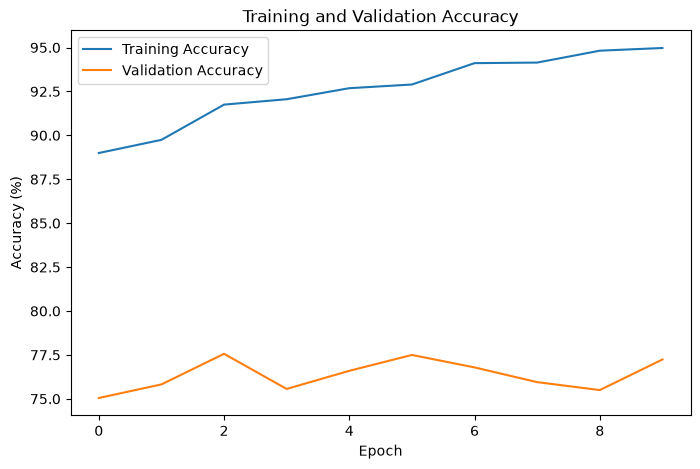

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.show()

In [59]:
model.load_state_dict(
    torch.load(
        "best_waste_cnn.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [60]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

In [61]:
import numpy as np

all_predictions = np.array(
    all_predictions
)

all_labels = np.array(
    all_labels
)

In [62]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_dataset.classes
    )
)

Test Accuracy: 76.29%
              precision    recall  f1-score   support

     battery       0.73      0.56      0.63        95
  biological       0.74      0.64      0.68        99
 brown-glass       0.84      0.62      0.72        61
   cardboard       0.77      0.73      0.75        89
     clothes       0.88      0.94      0.91       533
 green-glass       0.84      0.84      0.84        63
       metal       0.59      0.42      0.49        77
       paper       0.74      0.74      0.74       105
     plastic       0.62      0.53      0.57        86
       shoes       0.63      0.78      0.70       198
       trash       0.80      0.64      0.71        69
 white-glass       0.55      0.71      0.62        77

    accuracy                           0.76      1552
   macro avg       0.73      0.68      0.70      1552
weighted avg       0.76      0.76      0.76      1552



In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

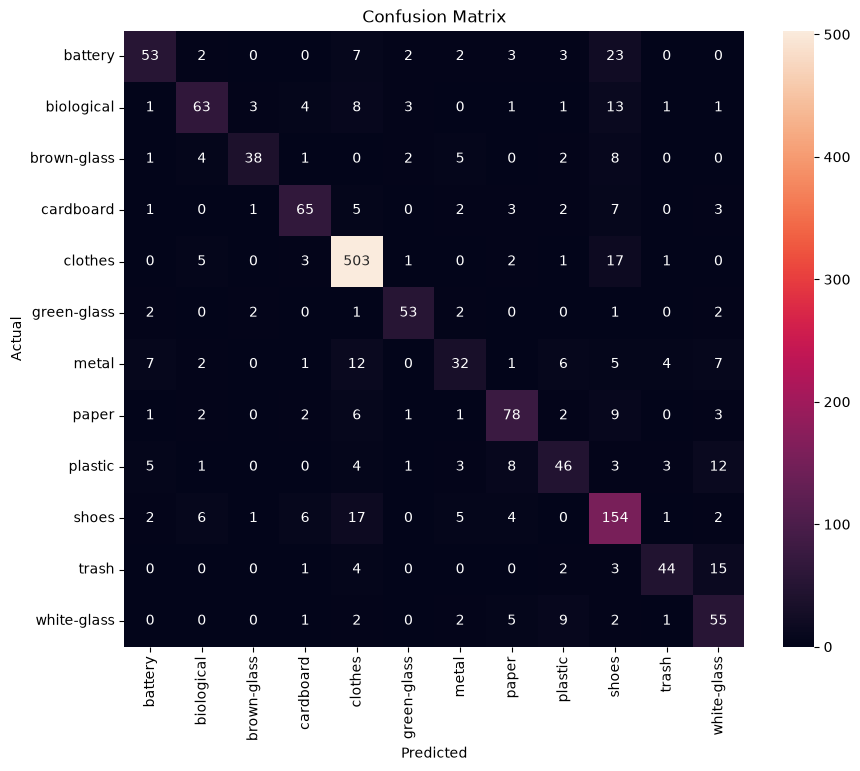

In [65]:
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [66]:
for i, class_name in enumerate(
    train_dataset.classes
):

    class_mask = (
        all_labels == i
    )

    class_correct = (
        all_predictions[class_mask] == i
    ).sum()

    class_total = class_mask.sum()

    class_accuracy = (
        100 * class_correct /
        class_total
    )

    print(
        f"{class_name}: "
        f"{class_accuracy:.2f}%"
    )

battery: 55.79%
biological: 63.64%
brown-glass: 62.30%
cardboard: 73.03%
clothes: 94.37%
green-glass: 84.13%
metal: 41.56%
paper: 74.29%
plastic: 53.49%
shoes: 77.78%
trash: 63.77%
white-glass: 71.43%


In [68]:
wrong_indices = np.where(
    all_labels != all_predictions
)[0]

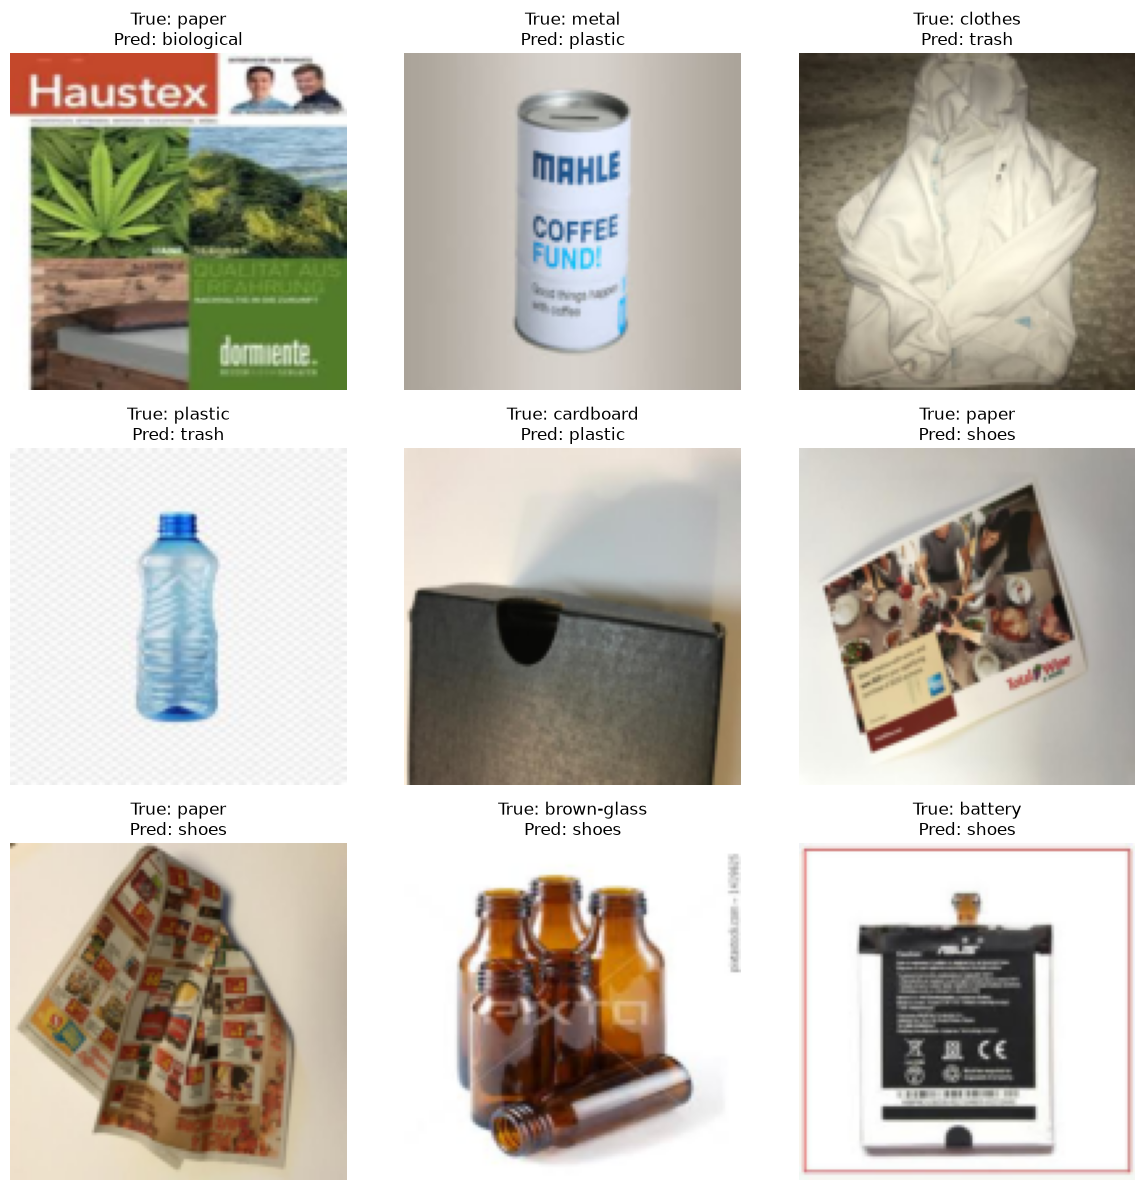

In [69]:
plt.figure(figsize=(12, 12))

for plot_index, dataset_index in enumerate(
    wrong_indices[:9]
):

    image, true_label = test_dataset[
        dataset_index
    ]

    image = image.permute(
        1, 2, 0
    )

    image = image * 0.5 + 0.5

    predicted_label = all_predictions[
        dataset_index
    ]

    plt.subplot(3, 3, plot_index + 1)

    plt.imshow(image)

    plt.title(
        f"True: "
        f"{train_dataset.classes[true_label]}\n"
        f"Pred: "
        f"{train_dataset.classes[predicted_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [71]:
from PIL import Image
def predict_image(
    image_path,
    model,
    transform,
    classes,
    device
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = transform(
        image
    )

    image_tensor = image_tensor.unsqueeze(
        0
    )

    image_tensor = image_tensor.to(
        device
    )

    model.eval()

    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predicted_index = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_index
        ].item()

    predicted_class = classes[
        predicted_index
    ]

    return predicted_class, confidence


In [75]:
import json

class_names = train_dataset.classes

with open(
    "class_names.json",
    "w"
) as f:

    json.dump(
        class_names,
        f
    )
    

In [77]:
torch.save(
    model.state_dict(),
    "best_waste_cnn.pth"
)
model = WasteCNN(
    num_classes=len(class_names)
)

model.load_state_dict(
    torch.load(
        "best_waste_cnn.pth",
        map_location=device
    )
)

model.to(device)

model.eval()

WasteCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=12, bias=True)
)